This is a notebook that tries out the center of rotation estimator in muhrec and compares it to the one in cil. Sor far, it was found that center = imgalg.TomoCenter()
est = center.estimate(img0, img181, pm.centerCorrelation, False) gives approximately the same result as cil does. There is also a similar least squares version which gives approx the same.

In [55]:
import sys
import os

# Add the desired directory to the sys.path
path_to_add = '/dtu-compute/msaca/muhrec_folder2/build-imagingsuite/Release/lib/'
sys.path.append(path_to_add)
path_to_add = '/dtu-compute/msaca/muhrec_folder2/amglib/CBCTCalibration/'
sys.path.append(path_to_add)
path_to_add = '/dtu-compute/msaca/muhrec_folder2/imagingsuite/package/'
sys.path.append(path_to_add)
path_to_add = '/zhome/71/c/146676/Desktop/msaca/main/'
sys.path.append(path_to_add)

In [56]:
import advfilters
from cil.io import TIFFStackReader
import imgalg
import numpy as np
import amglib.readers as io
import pymuhrec as pm
import matplotlib.pyplot as plt
from astropy.io import fits
from extended_data import ExtendedData

In [60]:
path = '/work3/msaca/Mars_data_1/02_sinogramdata/sinograms/ABC_2/sinocleaned_#####.tif'
#reader = TIFFStackReader(path)
#data1 = reader.read()

In [61]:
skip = 1
slices = np.arange(100, 1006, skip)
sinograms = ExtendedData()
sinograms.load_data(path = path, slices = slices)
sinograms.scale_data(scale=1/2500,offset=-12)
sinograms.pad_edges()

In [79]:
data1 = sinograms.data
np.shape(data1)

(906, 1126, 1698)

In [74]:
k = 100
p180 = 1125//2
img0 = (data1[:,k,:])
img180 = data1[:,k+p180,:]
img181  =data1[:, k+p180+1,:]

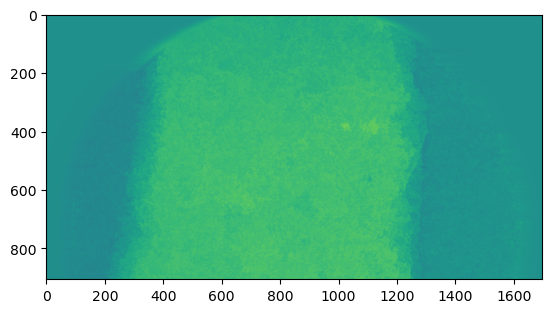

In [75]:
plt.imshow(img0)
plt.clim([-0.2,0.2])

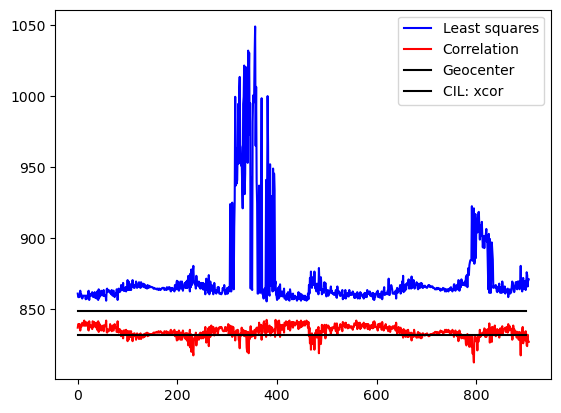

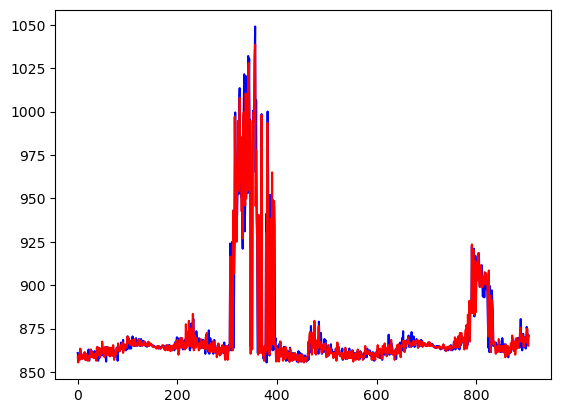

In [83]:
geo_center = 1698//2

center = imgalg.TomoCenter()
est = center.estimate(img0, img180, pm.centerLeastSquare, False)
centers1 = center.centers()
center = imgalg.TomoCenter()
est = center.estimate(img0, img180, pm.centerCorrelation, False)
centers2 = center.centers()
plt.plot(centers1, color='blue')
plt.plot(centers2, color='red')
plt.plot(np.array((0,900)), np.array((geo_center, geo_center)), color='black')
plt.plot(np.array((0,900)), np.array((geo_center-17, geo_center-17)), color='black')
plt.legend(('Least squares', 'Correlation','Geocenter', 'CIL: xcor'))
plt.show()
center = imgalg.TomoCenter()
est = center.estimate(img0, img180, pm.centerLeastSquare, False)
centers1 = center.centers()
center = imgalg.TomoCenter()
est = center.estimate(img0, img181, pm.centerLeastSquare, False)
centers2 = center.centers()
plt.plot(centers1, color='blue')
plt.plot(centers2, color='red')
plt.show()

This is interesting!! Let's try to make it more accurate by not only picking 2 projections but many more:

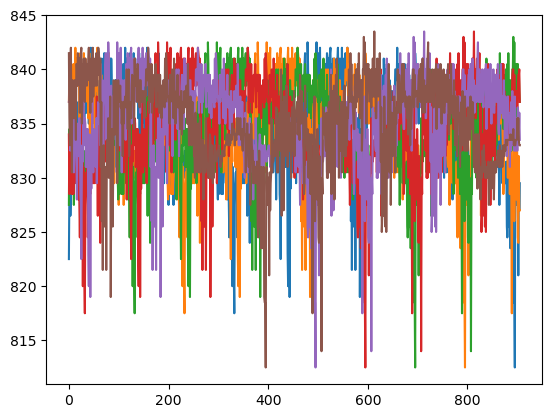

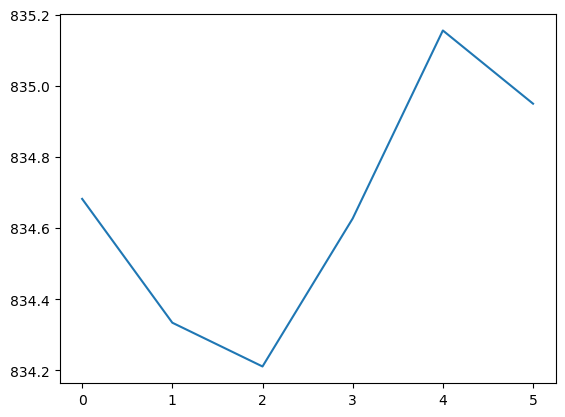

In [94]:
i = -1
centers2 = np.empty((6, 906))
for k in range(0,550, 100):
    i = i+1
    img0 = (data1[:,k,:])
    img180 = data1[:,k+p180,:]
    img181  =data1[:, k+p180+1,:]
    center = imgalg.TomoCenter()
    est = center.estimate(img0, img180, pm.centerCorrelation, False)
    centers2[i] = center.centers()
    plt.plot(centers2[i])
plt.show()

plt.figure()
center = np.mean(centers2,axis=1)
plt.plot(center)
plt.show()

In [109]:
center = imgalg.TomoCenter()
est = center.estimate(img0, img180, pm.centerCorrelation, True)
est

(835.3516272974939, 0.1614061628260998, 453.0)

<eCenterEstimator.centerCenterOfGravity: 2>

In [22]:
def read_fits_stack_to_numpy(file_prefix, start_num, end_num, file_extension=".fits"):
    fits_data = []

    for i in range(start_num, end_num + 1):
        # Format the filename with zero-padded numbers
        file_name = f"{file_prefix}_{i:05d}{file_extension}"

        # Check if the file exists before reading it
        if os.path.exists(file_name):
            with fits.open(file_name) as hdul:
                # Append the primary HDU (the first extension) data to the list
                fits_data.append(hdul[0].data)
        else:
            print(f"File {file_name} not found.")

    # Convert the list to a NumPy array
    fits_array = np.array(fits_data)
    return fits_array

In [ ]:
path = '/dtu-compute/msaca/sliceA_neutron_psi/ct_1x1126_60s/ct_1x1126_60s'
data2 = read_fits_stack_to_numpy(path, start_num=1, end_num=1126)

In [ ]:
np.shape(data2)

(1126, 2048, 2048)

In [ ]:
k = 100
p180 = 1125//2
img0 = data2[k,:,:]
img180 = data2[k+p180,:,:]
img181  =data2[k+p180+1,:,:]

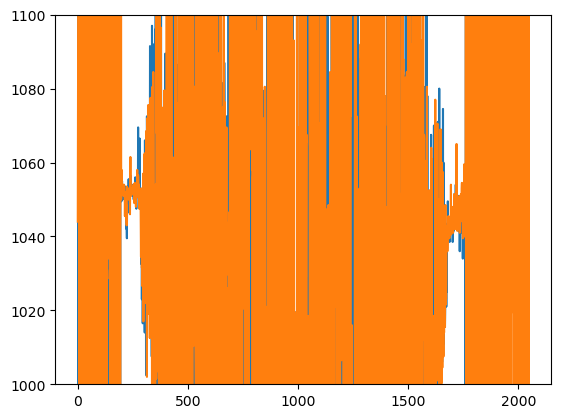

In [28]:
center = imgalg.TomoCenter()
est = center.estimate(img0, img180, pm.centerLeastSquare, False)
centers1 = center.centers()
center = imgalg.TomoCenter()
est = center.estimate(img0, img181, pm.centerLeastSquare, False)
centers2 = center.centers()
plt.plot(centers1)
plt.plot(centers2)
plt.ylim([1000,1100])
plt.show()